In [1]:
!pip install opencv-python ipywidgets

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path, 0)

# Convert to binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.1 MB/s eta 0:00:00


Saving microsoft-copilot-71ig274jGpw-unsplash.jpg to microsoft-copilot-71ig274jGpw-unsplash.jpg


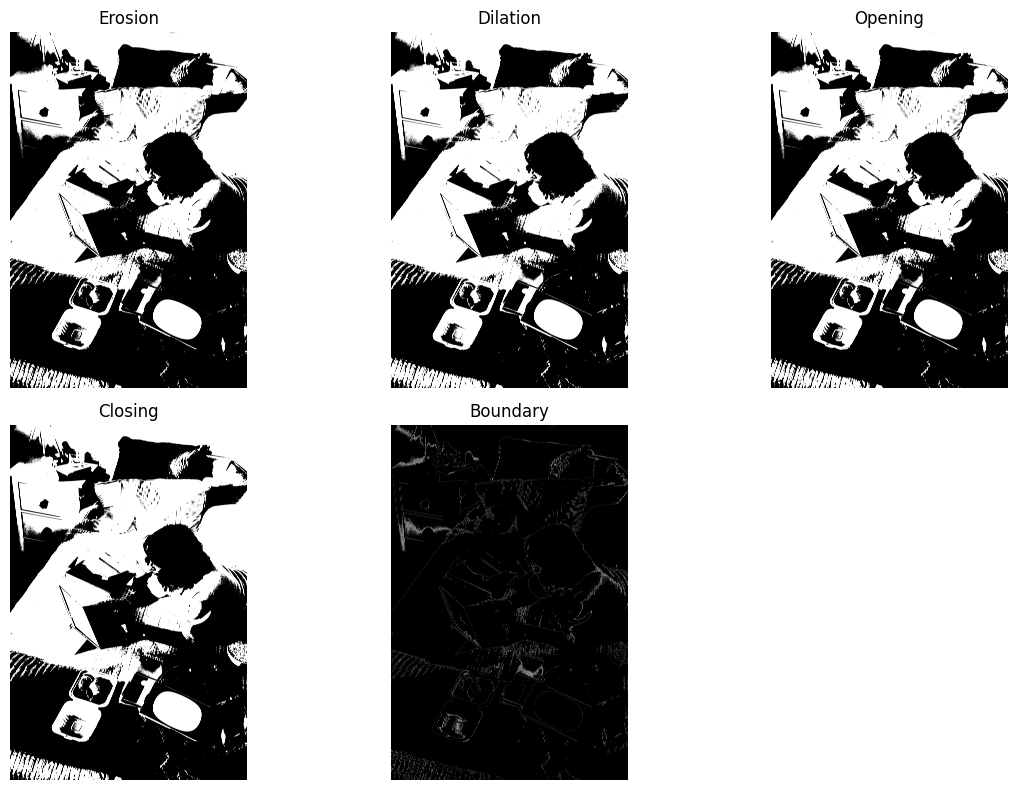

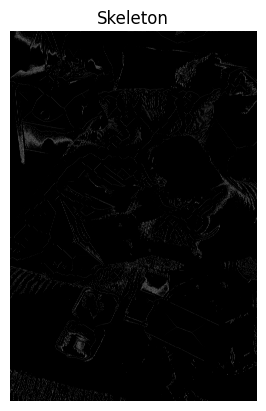

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Convert to binary
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')
plt.show()

# ----------------------------
# MORPHOLOGY FUNCTION
# ----------------------------
def morphology(kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    erosion = cv2.erode(binary, kernel, iterations=1)
    dilation = cv2.dilate(binary, kernel, iterations=1)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    boundary = binary - erosion

    plt.figure(figsize=(12,8))

    titles = ["Erosion", "Dilation", "Opening", "Closing", "Boundary"]
    images = [erosion, dilation, opening, closing, boundary]

    for i in range(len(images)):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Interactive slider (OUTSIDE function)
widgets.interact(morphology, kernel_size=widgets.IntSlider(min=1, max=15, step=2, value=3))


# ----------------------------
# SKELETONIZATION
# ----------------------------
def skeletonize(img):
    size = np.size(img)
    skel = np.zeros(img.shape, np.uint8)

    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
    done = False

    while not done:
        eroded = cv2.erode(img, element)
        temp = cv2.dilate(eroded, element)
        temp = cv2.subtract(img, temp)
        skel = cv2.bitwise_or(skel, temp)
        img = eroded.copy()

        zeros = size - cv2.countNonZero(img)
        if zeros == size:
            done = True

    return skel


# Apply skeletonization
skeleton = skeletonize(binary)

plt.imshow(skeleton, cmap='gray')
plt.title("Skeleton")
plt.axis('off')
plt.show()